## Análisis de accidentes - Buses

### Area metropolitana del Valle de Aburrá

Manuela Cordoba

Alejandro Fernandez

Ana María Jaramillo


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pycaret.classification import *
from sklearn.model_selection import train_test_split
from imblearn.combine import *
import config

In [42]:
dataset_for_spatial_analysis = pd.read_csv(config.DATASET_WITH_SPATIAL_INFO)

#! Changing the class "material_damage_only" for "damage_only" in the column severity,
#! for being considered as 0 in the model and read the metrics straightforward
dataset_for_spatial_analysis["severity"] = dataset_for_spatial_analysis[
    "severity"
].replace("material_damage_only", "damage_only")

In [43]:
dataset_for_spatial_analysis.columns

Index(['geoco_type', 'severity', 'month', 'day', 'area_code',
       'user_category_code', 'subcategory', 'hierarchy', 'road_class',
       'stratum', 'accident_type', 'vehicle_class', 'service_type', 'brand',
       'model', 'zone', 'design', 'driver_age', 'gender', 'weekday', 'hour',
       'GiZScore_Count', 'GiPValue_Count', 'GiZScore_Severity',
       'GiPValue_Severity', 'NNeighbors_Severity', 'LMiIndex_Anselin_Count',
       'LMiZScore_Anselin_Count', 'LMiPValue_Anselin_Count',
       'COType_Anselin_Count', 'NNeighbors_Anselin_Count',
       'SpatialLag_Anselin_Count', 'LMiIndex_Anselin_Sev',
       'LMiZScore_Anselin_Sev', 'COType_Anselin_Sev',
       'ZTransform_Anselin_Sev'],
      dtype='object')

In [44]:
columns_list = [
    col for col in dataset_for_spatial_analysis.columns if col != "severity"
]

# Separate numeric and string columns
numeric_columns = []
string_columns = []

# Check if each column is numeric or contains strings
for col in columns_list:
    if (
        pd.to_numeric(dataset_for_spatial_analysis[col], errors="coerce")
        .notnull()
        .all()
    ):
        numeric_columns.append(col)
    else:
        string_columns.append(col)

# Print numeric and string columns
print("Numeric Columns:", numeric_columns)
print("String Columns:", string_columns)

Numeric Columns: ['month', 'day', 'user_category_code', 'hierarchy', 'road_class', 'stratum', 'model', 'driver_age', 'hour']
String Columns: ['geoco_type', 'area_code', 'subcategory', 'accident_type', 'vehicle_class', 'service_type', 'brand', 'zone', 'design', 'gender', 'weekday', 'GiZScore_Count', 'GiPValue_Count', 'GiZScore_Severity', 'GiPValue_Severity', 'NNeighbors_Severity', 'LMiIndex_Anselin_Count', 'LMiZScore_Anselin_Count', 'LMiPValue_Anselin_Count', 'COType_Anselin_Count', 'NNeighbors_Anselin_Count', 'SpatialLag_Anselin_Count', 'LMiIndex_Anselin_Sev', 'LMiZScore_Anselin_Sev', 'COType_Anselin_Sev', 'ZTransform_Anselin_Sev']


In [45]:
# Remove 'month' and 'day' from the numeric columns list
numeric_columns.remove("month")
numeric_columns.remove("day")

# Add 'month' and 'day' to the string columns list
string_columns.extend(["month", "day"])

# Print numeric and string columns
print("Numeric Columns:", numeric_columns)
print("String Columns:", string_columns)

Numeric Columns: ['user_category_code', 'hierarchy', 'road_class', 'stratum', 'model', 'driver_age', 'hour']
String Columns: ['geoco_type', 'area_code', 'subcategory', 'accident_type', 'vehicle_class', 'service_type', 'brand', 'zone', 'design', 'gender', 'weekday', 'GiZScore_Count', 'GiPValue_Count', 'GiZScore_Severity', 'GiPValue_Severity', 'NNeighbors_Severity', 'LMiIndex_Anselin_Count', 'LMiZScore_Anselin_Count', 'LMiPValue_Anselin_Count', 'COType_Anselin_Count', 'NNeighbors_Anselin_Count', 'SpatialLag_Anselin_Count', 'LMiIndex_Anselin_Sev', 'LMiZScore_Anselin_Sev', 'COType_Anselin_Sev', 'ZTransform_Anselin_Sev', 'month', 'day']


In [46]:
# Get unique values in the 'severity' column
dataset_for_spatial_analysis["severity"].unique()

array(['injured', 'damage_only', 'fatality'], dtype=object)

In [47]:
# Replace 'fatality' with 'injured'
dataset_for_spatial_analysis["severity"] = dataset_for_spatial_analysis[
    "severity"
].replace("fatality", "injured")

# Verify the changes by checking unique values again
unique_values_after = dataset_for_spatial_analysis["severity"].unique()
print("Unique values after replacement:", unique_values_after)

Unique values after replacement: ['injured' 'damage_only']


In [48]:
dataset_for_spatial_analysis["severity"].value_counts(normalize=True)

severity
damage_only    0.752566
injured        0.247434
Name: proportion, dtype: float64

In [49]:
dataset_for_spatial_analysis.head()

,geoco_type,severity,month,day,area_code,user_category_code,subcategory,hierarchy,road_class,stratum,...,LMiIndex_Anselin_Count,LMiZScore_Anselin_Count,LMiPValue_Anselin_Count,COType_Anselin_Count,NNeighbors_Anselin_Count,SpatialLag_Anselin_Count,LMiIndex_Anselin_Sev,LMiZScore_Anselin_Sev,COType_Anselin_Sev,ZTransform_Anselin_Sev
0,road_network,injured,2,25,high_mix_use_areas_and_corridors,3,centralities_with_economic_predominance,3.0,6.0,0,...,0.007202,0.464686,0.332,0,51.0,-0.068365,-0.004177,-0.090220,0,0.235915
1,road_network,damage_only,1,14,medium_mix_use_areas_and_corridors,2,transition_zones_centralities_endowment_areas_...,4.0,1.0,3,...,0.085740,3.966521,0.008,HH,54.0,0.639631,0.551312,3.141803,HH,1.188109
2,road_network,damage_only,1,14,medium_mix_use_areas_and_corridors,2,transition_zones_centralities_endowment_areas_...,4.0,1.0,3,...,0.085740,3.966521,0.008,HH,54.0,0.639631,0.551312,3.141803,HH,1.188109
3,road_network,damage_only,1,13,high_mix_use_areas_and_corridors,3,economically_transforming_areas,3.0,6.0,0,...,-0.089343,-0.945230,0.150,0,34.0,0.194088,0.328677,2.525698,HH,0.887363
4,road_network,damage_only,1,13,high_mix_use_areas_and_corridors,3,economically_transforming_areas,3.0,6.0,0,...,-0.089343,-0.945230,0.150,0,34.0,0.194088,0.328677,2.525698,HH,0.887363


Feature engineering.

Here, we can do some transformations to some features. For example:

- `is_weekend`: a new feature that indicates if the accident happened on a weekend.
- `is_night`: a new feature that indicates if the accident happened at night.
- `is_peak_time`: a new feature that indicates if the accident happened during peak hours. For this feature, I considered peak_time as the following hours:
  - Morning peak: 6:00 a.m. to 9:00 a.m.
  - Afternoon peak: 5:00 p.m. to 8:00 p.m.

Other possible features could be:

- `rainy_month`: a new feature that indicates if the accident happened in a month with high rainfall. For this, we can use the average rainfall for each month in Medellín. We can consider the months with higher rainfall as the rainy months: april, may, june, october, november, and december.


In [50]:
#  Changing day for "is_weekend" and hour by "is_night", and also creating "is_peak_time" (peak_time is considered if the hour is between 6 and 9, and if the hour is between 17 and 20)

dataset_for_spatial_analysis["is_weekend"] = dataset_for_spatial_analysis[
    "weekday"
].apply(lambda x: 1 if x in ["saturday", "sunday"] else 0)
dataset_for_spatial_analysis["is_night"] = dataset_for_spatial_analysis["hour"].apply(
    lambda x: 1 if x in range(0, 6) or x in range(21, 24) else 0
)
dataset_for_spatial_analysis["is_peak_time"] = dataset_for_spatial_analysis[
    "hour"
].apply(lambda x: 1 if x in range(6, 10) or x in range(17, 21) else 0)

In [51]:
dataset_for_spatial_analysis.head()

,geoco_type,severity,month,day,area_code,user_category_code,subcategory,hierarchy,road_class,stratum,...,COType_Anselin_Count,NNeighbors_Anselin_Count,SpatialLag_Anselin_Count,LMiIndex_Anselin_Sev,LMiZScore_Anselin_Sev,COType_Anselin_Sev,ZTransform_Anselin_Sev,is_weekend,is_night,is_peak_time
0,road_network,injured,2,25,high_mix_use_areas_and_corridors,3,centralities_with_economic_predominance,3.0,6.0,0,...,0,51.0,-0.068365,-0.004177,-0.090220,0,0.235915,0,0,0
1,road_network,damage_only,1,14,medium_mix_use_areas_and_corridors,2,transition_zones_centralities_endowment_areas_...,4.0,1.0,3,...,HH,54.0,0.639631,0.551312,3.141803,HH,1.188109,0,0,1
2,road_network,damage_only,1,14,medium_mix_use_areas_and_corridors,2,transition_zones_centralities_endowment_areas_...,4.0,1.0,3,...,HH,54.0,0.639631,0.551312,3.141803,HH,1.188109,0,0,1
3,road_network,damage_only,1,13,high_mix_use_areas_and_corridors,3,economically_transforming_areas,3.0,6.0,0,...,0,34.0,0.194088,0.328677,2.525698,HH,0.887363,0,0,1
4,road_network,damage_only,1,13,high_mix_use_areas_and_corridors,3,economically_transforming_areas,3.0,6.0,0,...,0,34.0,0.194088,0.328677,2.525698,HH,0.887363,0,0,1


In [52]:
dataset_for_spatial_analysis.columns

Index(['geoco_type', 'severity', 'month', 'day', 'area_code',
       'user_category_code', 'subcategory', 'hierarchy', 'road_class',
       'stratum', 'accident_type', 'vehicle_class', 'service_type', 'brand',
       'model', 'zone', 'design', 'driver_age', 'gender', 'weekday', 'hour',
       'GiZScore_Count', 'GiPValue_Count', 'GiZScore_Severity',
       'GiPValue_Severity', 'NNeighbors_Severity', 'LMiIndex_Anselin_Count',
       'LMiZScore_Anselin_Count', 'LMiPValue_Anselin_Count',
       'COType_Anselin_Count', 'NNeighbors_Anselin_Count',
       'SpatialLag_Anselin_Count', 'LMiIndex_Anselin_Sev',
       'LMiZScore_Anselin_Sev', 'COType_Anselin_Sev', 'ZTransform_Anselin_Sev',
       'is_weekend', 'is_night', 'is_peak_time'],
      dtype='object')

In [53]:
import sweetviz as sv

pre_model_severity_one_hot = pd.get_dummies(dataset_for_spatial_analysis['severity'], prefix='severity')

# Merge the one-hot encoded columns back into the original DataFrame
pre_model_data_with_one_hot = pd.concat([dataset_for_spatial_analysis, pre_model_severity_one_hot], axis=1)

pre_model_data_with_one_hot['severity_damage_only'] = pre_model_data_with_one_hot['severity_damage_only'].astype(int)
pre_model_data_with_one_hot['severity_injured'] = pre_model_data_with_one_hot['severity_injured'].astype(int)

my_feature_config_pre_model = sv.FeatureConfig(force_num=['severity_damage_only'])
condition_series_pre_model = pre_model_data_with_one_hot['severity_damage_only'] == 1

report_categories = sv.compare_intra(pre_model_data_with_one_hot, 
                             condition_series_pre_model, 
                             ['damage_only','injured'])

# Display the report in your Jupyter Notebook
report_categories.show_html(config.PRE_MODEL_DATA_REPORT_BY_CATEGORY)

                                             |          | [  0%]   00:00 -> (? left)

Report ../data/Pre_model_data_report_by_categpry.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [54]:
report = sv.analyze(dataset_for_spatial_analysis)

# Display the report in your Jupyter Notebook
report.show_html(config.TRANSLATED_DATA_REPORT)

                                             |          | [  0%]   00:00 -> (? left)

Report ../data/Translated_data_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(dataset_for_spatial_analysis, title="Dataset for spatial analysis summary Report", explorative=True)
#profile.to_file("../data/dataset_for_spatial_analysis_report.xlsx")
profile.to_file(config.DATASET_WITH_SPATIAL_INFO_REPORT)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 39/39 [00:00<00:00, 50.48it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

PermissionError: [Errno 13] Permission denied: '..\\data\\dataset_for_spatial_analysis_report.html'

In [ ]:
# Setup the model with manual data type specification
exp1 = setup(
    data=dataset_for_spatial_analysis,
    target="severity",
    ignore_features=[
        "weekday",
        "hour",
    ],  # ignore weekday and hour as they are already transformed
    fix_imbalance=True,
    session_id=2023,
    normalize=True,
    data_split_stratify=True,
    fold_strategy="stratifiedkfold",
    numeric_features=[col for col in numeric_columns if col != "hour"],
    categorical_features=[col for col in string_columns if col != "weekday"],
)  # ,
# ignore_features=['clase_acci'],
# normalize_method="zscore",
# transformation=True)

,Description,Value
0,Session id,2023
1,Target,severity
2,Target type,Binary
3,Target mapping,"damage_only: 0, injured: 1"
4,Original data shape,"(79112, 39)"
5,Transformed data shape,"(107086, 122)"
6,Transformed train set shape,"(83352, 122)"
7,Transformed test set shape,"(23734, 122)"
8,Ignore features,2
9,Numeric features,6


In [ ]:
train_model = compare_models(sort="Precision")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8561,0.8506,0.8561,0.8516,0.8460,0.5671,0.5840,2.4970
rf,Random Forest Classifier,0.8550,0.8453,0.8550,0.8495,0.8461,0.5690,0.5823,5.2800
gbc,Gradient Boosting Classifier,0.8546,0.8392,0.8546,0.8494,0.8450,0.5649,0.5801,12.4610
ada,Ada Boost Classifier,0.8509,0.8281,0.8509,0.8447,0.8417,0.5568,0.5697,3.8130
et,Extra Trees Classifier,0.8489,0.8415,0.8489,0.8422,0.8420,0.5609,0.5686,6.8900
svm,SVM - Linear Kernel,0.8438,0.8168,0.8438,0.8381,0.8373,0.5497,0.5574,1.5080
nb,Naive Bayes,0.8360,0.8052,0.8360,0.8286,0.8249,0.5089,0.5241,1.4020
ridge,Ridge Classifier,0.8287,0.8306,0.8287,0.8250,0.8265,0.5289,0.5296,1.5060
lda,Linear Discriminant Analysis,0.8287,0.8306,0.8287,0.8250,0.8265,0.5289,0.5296,2.1620
lr,Logistic Regression,0.8201,0.8320,0.8201,0.8203,0.8202,0.5175,0.5175,1.7470


In [ ]:
train_model = compare_models(sort="f1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8550,0.8453,0.8550,0.8495,0.8461,0.5690,0.5823,4.1840
lightgbm,Light Gradient Boosting Machine,0.8561,0.8506,0.8561,0.8516,0.8460,0.5671,0.5840,2.6150
gbc,Gradient Boosting Classifier,0.8546,0.8392,0.8546,0.8494,0.8450,0.5649,0.5801,14.0070
et,Extra Trees Classifier,0.8489,0.8415,0.8489,0.8422,0.8420,0.5609,0.5686,7.1800
ada,Ada Boost Classifier,0.8509,0.8281,0.8509,0.8447,0.8417,0.5568,0.5697,3.0450
svm,SVM - Linear Kernel,0.8438,0.8168,0.8438,0.8381,0.8373,0.5497,0.5574,1.3110
ridge,Ridge Classifier,0.8287,0.8306,0.8287,0.8250,0.8265,0.5289,0.5296,0.9020
lda,Linear Discriminant Analysis,0.8287,0.8306,0.8287,0.8250,0.8265,0.5289,0.5296,2.4490
nb,Naive Bayes,0.8360,0.8052,0.8360,0.8286,0.8249,0.5089,0.5241,0.9480
lr,Logistic Regression,0.8201,0.8320,0.8201,0.8203,0.8202,0.5175,0.5175,1.2940


In [ ]:
best = create_model("lightgbm")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8543,0.8455,0.8543,0.8498,0.8434,0.5588,0.5775
1,0.8530,0.8564,0.8530,0.8484,0.8419,0.5546,0.5734
2,0.8640,0.8632,0.8640,0.8605,0.8549,0.5926,0.6088
3,0.8602,0.8418,0.8602,0.8566,0.8501,0.5784,0.5964
4,0.8534,0.8434,0.8534,0.8481,0.8433,0.5596,0.5757
5,0.8530,0.8550,0.8530,0.8477,0.8428,0.5583,0.5745
6,0.8527,0.8507,0.8527,0.8467,0.8436,0.5621,0.5752
7,0.8559,0.8441,0.8559,0.8511,0.8461,0.5680,0.5839
8,0.8602,0.8553,0.8602,0.8573,0.8495,0.5758,0.5959


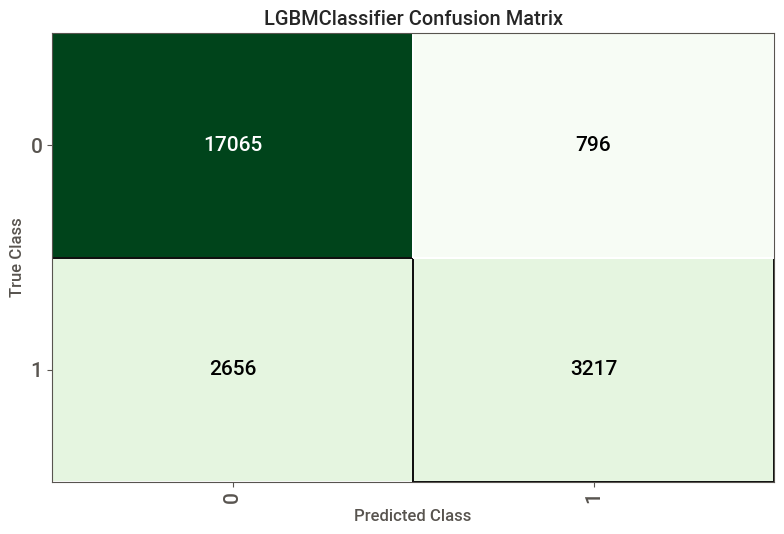

In [ ]:
plot_model(best, plot="confusion_matrix")

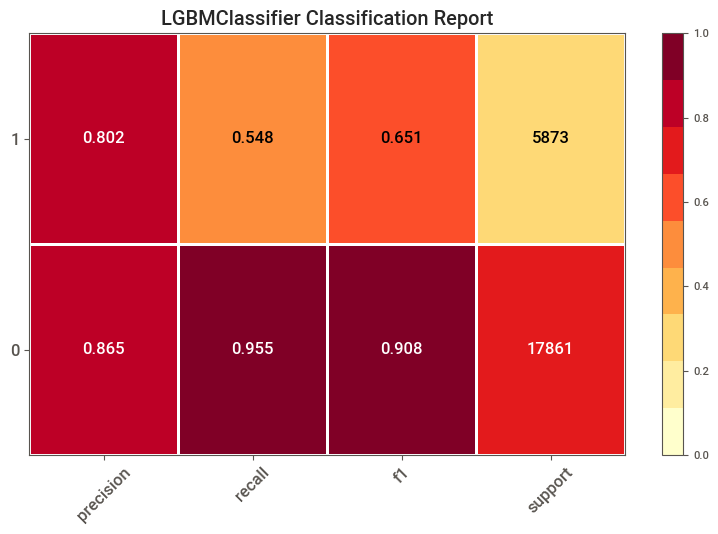

In [ ]:
plot_model(estimator=best, plot="class_report")

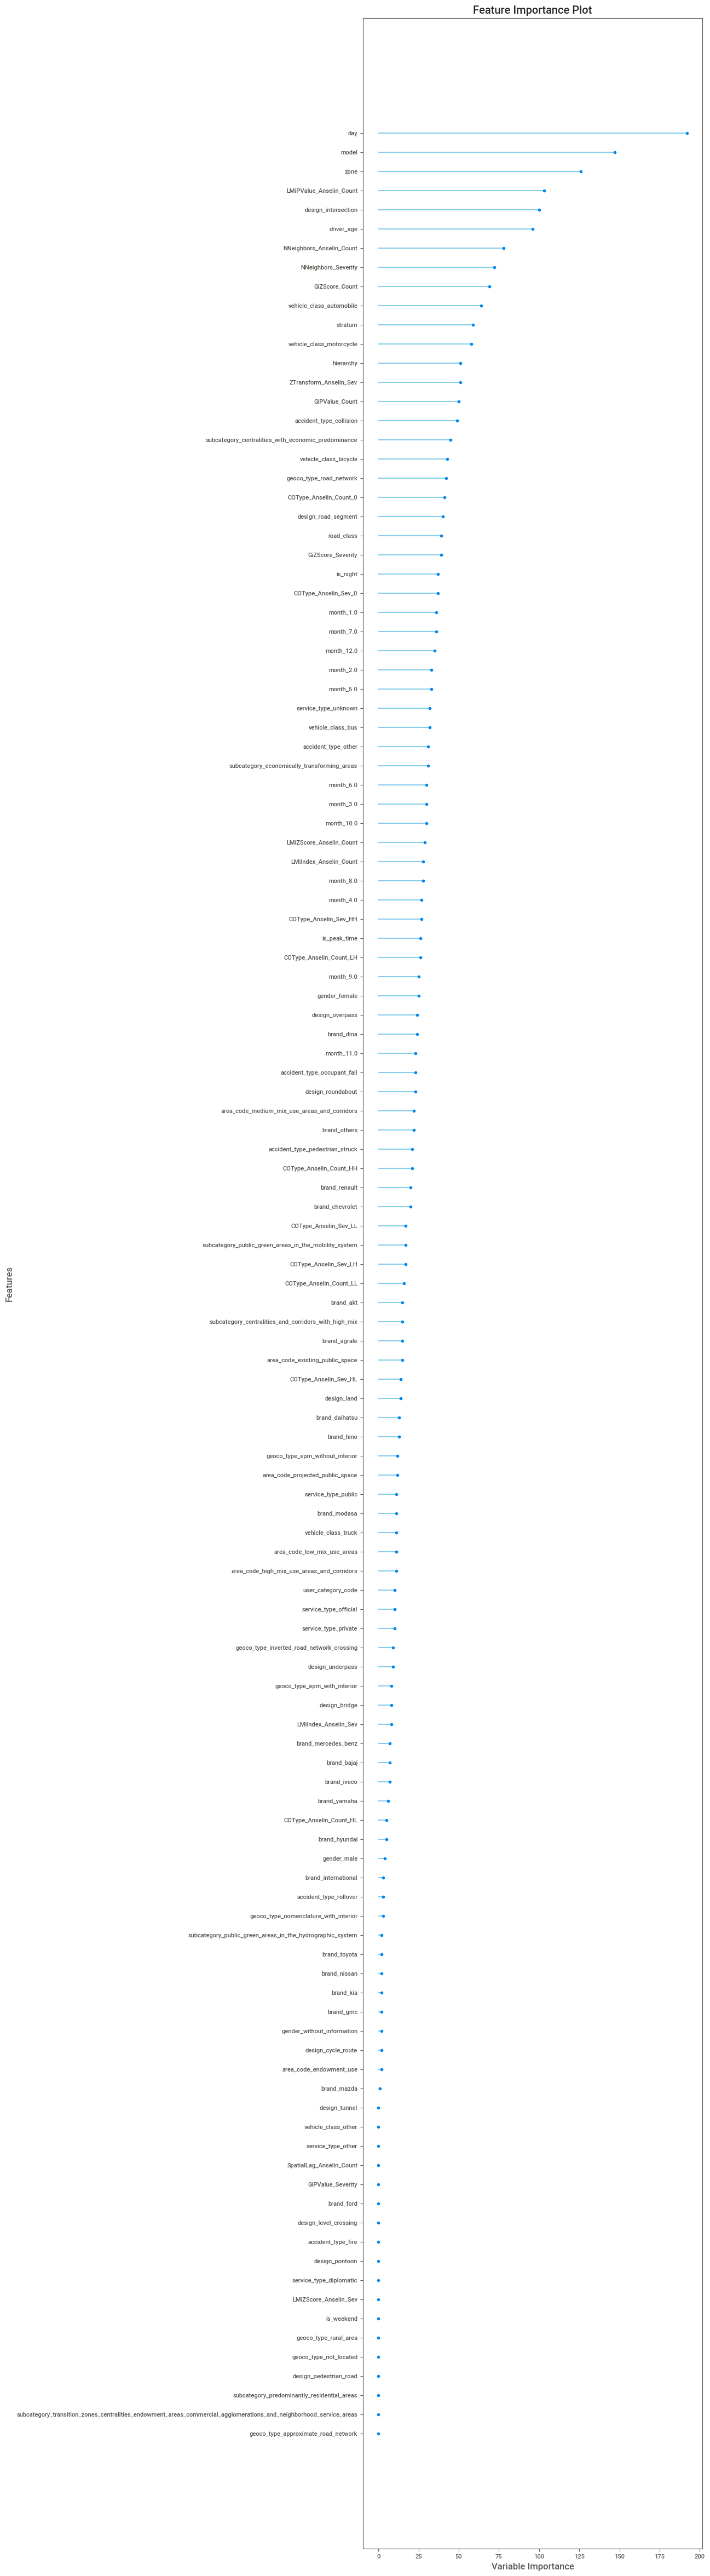

In [ ]:
# Visualize feature importance
plot_model(best, plot="feature_all")